<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Core Diagnostic 4 - Perturbative Models
---

This notebook diagnoses the perturbative density-profile models used by the core evolutor. It is paired with `tpeanuts.core.perturbative.test.test0_perturbative_models`, which contains the automated pytest checks. Here we keep plots and compact tables for the model interface, density evaluation, segment ordering, averages, and residual integrals.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: profile models, segment averages, and residual integrals |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Model-Selection-and-Interface) | **Model Selection and Interface** |
| [4](#4.-Even-Power-Model) | **Even-Power Model** |
| [5](#5.-PREM-Tabulated-Model) | **PREM Tabulated Model** |
| [6](#6.-Model-Comparison) | **Model Comparison** |
| [?](#7.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Perturbative Model Role

The perturbative core evolutor does not own a medium geometry. Instead, geometry modules provide crossed trajectory segments, and the perturbative model converts those segments into the quantities needed by the evolutor:

$$
\bar n_e = \frac{1}{L}\int_{x_1}^{x_2} n_e(x)\,dx,
\qquad
L=x_2-x_1,
$$

plus a residual integral for the non-constant part of the density. This keeps the spectral/evolution code independent of Earth, atmosphere, or any other medium-specific coordinate system.

### 0.2 Segment Average and Residual Density

Inside one segment, the density is decomposed as

$$
n_e(x)=\bar n_e + \delta n_e(x),
\qquad
\int_{x_1}^{x_2}\delta n_e(x)\,dx=0.
$$

The average density builds the zeroth-order Hamiltonian. The residual density builds the first-order correction through oscillatory integrals of the form

$$
I_{ab}=\int_{x_1}^{x_2}\delta n_e(x)\,
\exp\left[i(\lambda_b-\lambda_a)x\right]dx,
$$

with extra endpoint phases handled by the segment model according to the convention expected by `evolutor_first_order`.

### 0.3 Even-Power Model

The even-power model represents a local density profile as

$$
n_e(x)=a+b x^2+c x^4+\delta_1 x^6+\delta_2 x^8+\cdots.
$$

It is useful when the medium density has already been approximated by even powers of a radial or trajectory coordinate. The analytic average is obtained by integrating each monomial term.

### 0.4 PREM Tabulated Model

The PREM tabulated model stores each shell as a polynomial linear in $r^2$,

$$
n_e(r^2)=A+B r^2.
$$

After a trajectory-coordinate shift $r^2=x^2+s$, the same shell becomes

$$
n_e(x)=A+B s + B x^2,
$$

so the perturbative integral remains analytic while preserving the tabulated-shell structure.

### References

- A. M. Dziewonski and D. L. Anderson, *Preliminary reference Earth model*, Physics of the Earth and Planetary Interiors 25, 297-356 (1981).
- C. Giunti and C. W. Kim, *Fundamentals of Neutrino Physics and Astrophysics*, Oxford University Press, 2007.
- J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, Cambridge University Press, 2020: perturbative time evolution and spectral representations.

## 1. Libraries

All imports are centralized here. The notebook uses synthetic coefficients so it does not depend on external PREM or density-table files.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch

from tpeanuts.core.perturbative.models import (
    EvenPowerProfileLayered,
    EvenPowerProfileSegment,
    PerturbativeSegmentBatch,
    PremProfileSegment,
    PremTabulatedProfile,
    perturbative_profile_selection,
)
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration

### 2.1 Paths

Figures are written under the diagnostic/core output directory, matching the relative notebook path below `notebooks/`.

In [2]:
config = load_notebook_config()
OUTPUT_DIR = config.output_dir("diagnostic", "core")
SHOW_PLOTS = config.show_plots

print(f"Repository root: {config.package_dir}")
print(f"Figure output directory: {OUTPUT_DIR}")

Repository root: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Figure output directory: v:\output\diagnostic\core


### 2.2 Configuration

The diagnostic uses three synthetic layers. The values are chosen to be smooth, positive, and visually distinct; they are not intended to reproduce a physical Earth profile.

**Expected results**: both model families should produce finite densities, finite segment averages, and zero residual correction for explicitly constant segments.

In [3]:
ctx = RuntimeContext.resolve(config.device, config.dtype)
CDTYPE = torch.complex128 if ctx.dtype == torch.float64 else torch.complex64

EVEN_COEFFICIENTS = torch.tensor(
    [
        [1.10, 0.10, 0.010],
        [1.55, 0.18, 0.018],
        [2.05, 0.28, 0.030],
    ],
    device=ctx.device,
    dtype=ctx.dtype,
)
PREM_COEFFICIENTS = torch.tensor(
    [
        [1.10, 0.12],
        [1.55, 0.20],
        [2.05, 0.32],
    ],
    device=ctx.device,
    dtype=ctx.dtype,
)
LAYER_BOUNDARIES = torch.tensor([[0.25, 0.55, 0.90]], device=ctx.device, dtype=ctx.dtype)
CROSSED = torch.tensor([[True, True, True]], device=ctx.device)
X_GRID = torch.linspace(0.0, 1.0, 250, device=ctx.device, dtype=ctx.dtype)
EIGENVALUES = torch.tensor([0.20, 0.55, 0.95], device=ctx.device, dtype=CDTYPE)

print("Even-power coefficients shape:", tuple(EVEN_COEFFICIENTS.shape))
print("PREM coefficients shape:", tuple(PREM_COEFFICIENTS.shape))
print("Layer boundaries:", LAYER_BOUNDARIES)

Even-power coefficients shape: (3, 3)
PREM coefficients shape: (3, 2)
Layer boundaries: tensor([[2.500000e-01, 5.500000e-01, 9.000000e-01]], dtype=torch.float64)


### 2.3 Local Helpers

Only small plotting helpers are defined here to keep the diagnostic cells readable.

In [4]:
def plot_density_family(x_grid, values, labels, title, filename):
    fig, ax = plt.subplots(figsize=(7.8, 4.2))
    x_np = to_numpy(x_grid)
    values_np = to_numpy(values)
    for i, label in enumerate(labels):
        ax.plot(x_np, values_np[:, i], lw=1.8, label=label)
    ax.set_xlabel("Trajectory coordinate x")
    ax.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


def plot_residual_matrix(matrix, title, filename):
    fig, ax = plt.subplots(figsize=(5.0, 4.2))
    im = ax.imshow(np.abs(to_numpy(matrix)), cmap="viridis")
    ax.set_title(title)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xlabel("b")
    ax.set_ylabel("a")
    fig.colorbar(im, ax=ax, label=r"$|I_{ab}|$")
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 3. Model Selection and Interface

The public selection helper maps string names to concrete layered models. The interface dataclasses carry segment geometry plus opaque model-specific data.

**Expected results**: aliases should instantiate the expected classes, and ordered segments should preserve the rectangular segment tensors expected by the evolutor pipeline.

In [5]:
even_selected = perturbative_profile_selection(
    "even-power",
    {"coefficients": EVEN_COEFFICIENTS, "device": ctx.device, "dtype": ctx.dtype},
)
prem_selected = perturbative_profile_selection(
    "prem500",
    {
        "coefficients": PREM_COEFFICIENTS,
        "rj": LAYER_BOUNDARIES.squeeze(0),
        "device": ctx.device,
        "dtype": ctx.dtype,
    },
)

selection_rows = [
    ("even-power", type(even_selected).__name__, tuple(even_selected.coefficients.shape)),
    ("prem500", type(prem_selected).__name__, tuple(prem_selected.coefficients.shape)),
]
for name, cls_name, shape in selection_rows:
    print(f"{name:12s} -> {cls_name:24s} coefficients={shape}")

batched_even = EvenPowerProfileLayered(coefficients=EVEN_COEFFICIENTS.unsqueeze(0), device=ctx.device, dtype=ctx.dtype)
segments = batched_even.ordered_segments(LAYER_BOUNDARIES, CROSSED)
print("segment x1:", segments.x1)
print("segment x2:", segments.x2)
print("segment crossed:", segments.crossed)
print("segment model_data shape:", tuple(segments.model_data.shape))

even-power   -> EvenPowerProfileLayered  coefficients=(3, 3)
prem500      -> PremTabulatedProfile     coefficients=(3, 2)
segment x1: tensor([[5.500000e-01, 2.500000e-01, 0.000000e+00]], dtype=torch.float64)
segment x2: tensor([[9.000000e-01, 5.500000e-01, 2.500000e-01]], dtype=torch.float64)
segment crossed: tensor([[True, True, True]])
segment model_data shape: (1, 3, 3)


## 4. Even-Power Model

### 4.1 Layered Density Evaluation

Each layer is evaluated as $a+b x^2+c x^4$ in this synthetic example.

**Expected results**: the three curves should be smooth and ordered mostly by their constant term, with mild curvature from the higher powers.

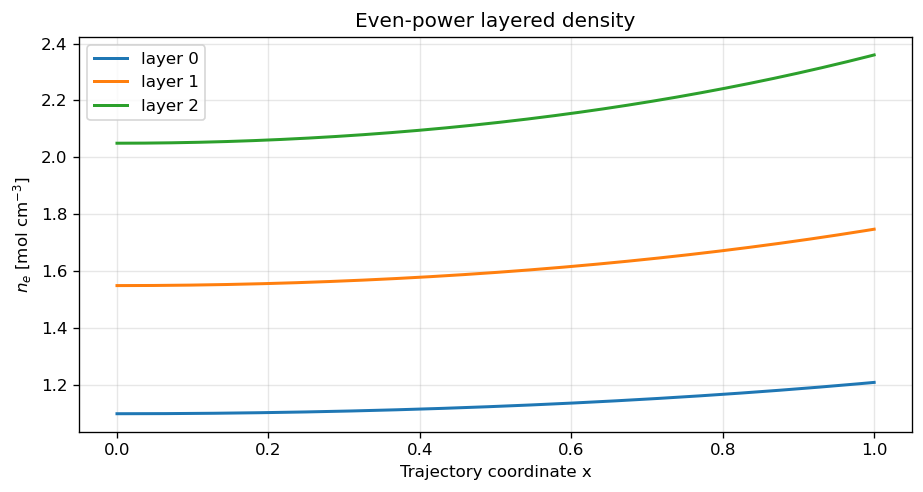

v:\output\diagnostic\core\diagnostic4_fig4_1_even_power_density.png


In [6]:
even_profile = EvenPowerProfileLayered(coefficients=EVEN_COEFFICIENTS, device=ctx.device, dtype=ctx.dtype)
even_values = even_profile.evaluate(X_GRID[:, None])
plot_density_family(
    X_GRID,
    even_values,
    ["layer 0", "layer 1", "layer 2"],
    "Even-power layered density",
    "diagnostic4_fig4_1_even_power_density.png",
)

### 4.2 Segment Average and Residual Integral

A non-constant even-power segment has a finite residual integral, while a constant segment should report no perturbation.

**Expected results**: the diagonal residual entries are zero by the model convention for degenerate spectral pairs, and the constant segment has `has_perturbation=False`.

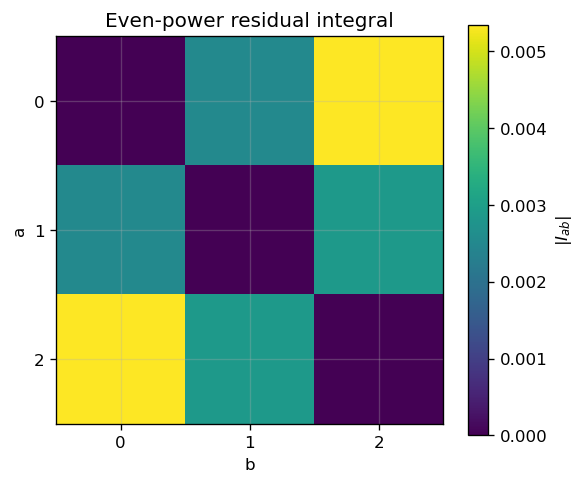

v:\output\diagnostic\core\diagnostic4_fig4_2_even_power_residual.png
even average: tensor(1.150039e+00, dtype=torch.float64)
even has perturbation: tensor(True)
constant even average: tensor(1.100000e+00, dtype=torch.float64)
constant even has perturbation: tensor(False)
max constant residual: 0.0


In [7]:
even_segment = EvenPowerProfileSegment(
    x1=torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype),
    x2=torch.tensor(0.75, device=ctx.device, dtype=ctx.dtype),
    a=torch.tensor(1.10, device=ctx.device, dtype=ctx.dtype),
    b=torch.tensor(0.25, device=ctx.device, dtype=ctx.dtype),
    c=torch.tensor(0.05, device=ctx.device, dtype=ctx.dtype),
    device=ctx.device,
    dtype=ctx.dtype,
)
even_constant = EvenPowerProfileSegment.constant(
    x1=torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype),
    x2=torch.tensor(0.75, device=ctx.device, dtype=ctx.dtype),
    density=torch.tensor(1.10, device=ctx.device, dtype=ctx.dtype),
    device=ctx.device,
    dtype=ctx.dtype,
)
even_residual = even_segment.residual_integral(EIGENVALUES[:, None], EIGENVALUES[None, :])

plot_residual_matrix(
    even_residual,
    "Even-power residual integral",
    "diagnostic4_fig4_2_even_power_residual.png",
)
print("even average:", even_segment.average)
print("even has perturbation:", even_segment.has_perturbation())
print("constant even average:", even_constant.average)
print("constant even has perturbation:", even_constant.has_perturbation())
print("max constant residual:", torch.max(torch.abs(even_constant.residual_integral(EIGENVALUES[:, None], EIGENVALUES[None, :]))).item())

## 5. PREM Tabulated Model

### 5.1 Shifted Layered Density Evaluation

The PREM-style model is linear in $r^2$. A trajectory shift $r^2=x^2+s$ modifies only the constant term.

**Expected results**: after the shift, all curves remain linear in $x^2$, with layer-dependent slopes inherited from the synthetic PREM coefficients.

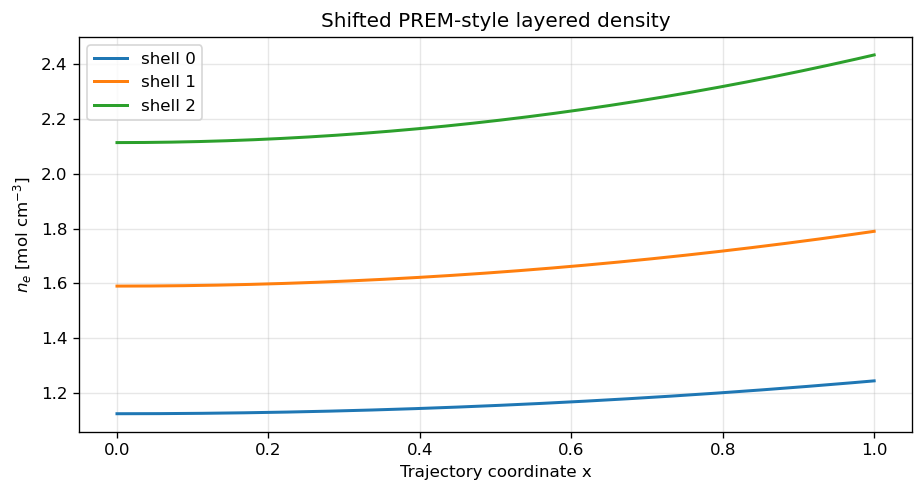

v:\output\diagnostic\core\diagnostic4_fig5_1_prem_density.png
original A: tensor([1.100000e+00, 1.550000e+00, 2.050000e+00], dtype=torch.float64)
shifted A: tensor([1.124000e+00, 1.590000e+00, 2.114000e+00], dtype=torch.float64)


In [8]:
prem_profile = PremTabulatedProfile(
    rj=LAYER_BOUNDARIES.squeeze(0),
    coefficients=PREM_COEFFICIENTS,
    device=ctx.device,
    dtype=ctx.dtype,
)
prem_shifted = prem_profile.shifted(torch.tensor(0.20, device=ctx.device, dtype=ctx.dtype))
prem_values = prem_shifted.evaluate(X_GRID[:, None])
plot_density_family(
    X_GRID,
    prem_values,
    ["shell 0", "shell 1", "shell 2"],
    "Shifted PREM-style layered density",
    "diagnostic4_fig5_1_prem_density.png",
)
print("original A:", prem_profile.coefficients[..., 0])
print("shifted A:", prem_shifted.coefficients[..., 0])

### 5.2 Segment Average and Residual Integral

For a PREM-style segment $n_e(x)=A+B x^2$, the average depends on the mean value of $x^2$ over the segment. A zero-slope segment is constant and has no perturbative residual.

**Expected results**: nonzero $B$ gives a finite off-diagonal residual matrix; $B=0$ removes the perturbation.

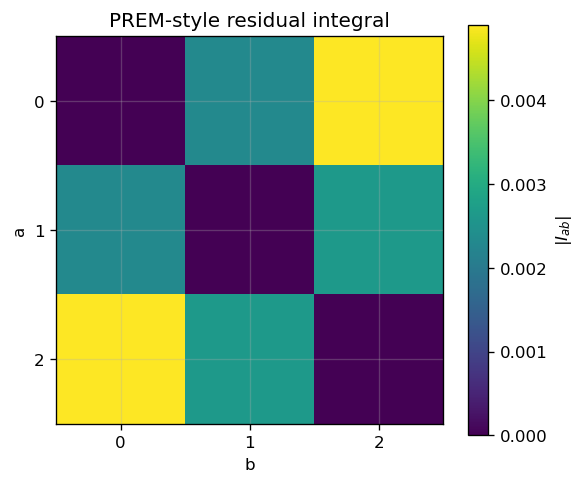

v:\output\diagnostic\core\diagnostic4_fig5_2_prem_residual.png
prem average: tensor(1.146875e+00, dtype=torch.float64)
prem has perturbation: tensor(True)
constant prem average: tensor(1.100000e+00, dtype=torch.float64)
constant prem has perturbation: tensor(False)
max constant residual: 0.0


In [9]:
prem_segment = PremProfileSegment(
    x1=torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype),
    x2=torch.tensor(0.75, device=ctx.device, dtype=ctx.dtype),
    a=torch.tensor(1.10, device=ctx.device, dtype=ctx.dtype),
    b=torch.tensor(0.25, device=ctx.device, dtype=ctx.dtype),
    device=ctx.device,
    dtype=ctx.dtype,
)
prem_constant = PremProfileSegment(
    x1=torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype),
    x2=torch.tensor(0.75, device=ctx.device, dtype=ctx.dtype),
    a=torch.tensor(1.10, device=ctx.device, dtype=ctx.dtype),
    b=torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype),
    device=ctx.device,
    dtype=ctx.dtype,
)
prem_residual = prem_segment.residual_integral(EIGENVALUES[:, None], EIGENVALUES[None, :])

plot_residual_matrix(
    prem_residual,
    "PREM-style residual integral",
    "diagnostic4_fig5_2_prem_residual.png",
)
print("prem average:", prem_segment.average)
print("prem has perturbation:", prem_segment.has_perturbation())
print("constant prem average:", prem_constant.average)
print("constant prem has perturbation:", prem_constant.has_perturbation())
print("max constant residual:", torch.max(torch.abs(prem_constant.residual_integral(EIGENVALUES[:, None], EIGENVALUES[None, :]))).item())

## 6. Model Comparison

This comparison overlays one even-power segment and one PREM-style segment with similar low-order coefficients. It helps separate differences caused by the quartic term from the shared quadratic structure.

**Expected results**: the curves agree near the origin when the constant and quadratic terms match, then diverge gradually because the even-power segment contains the quartic term.

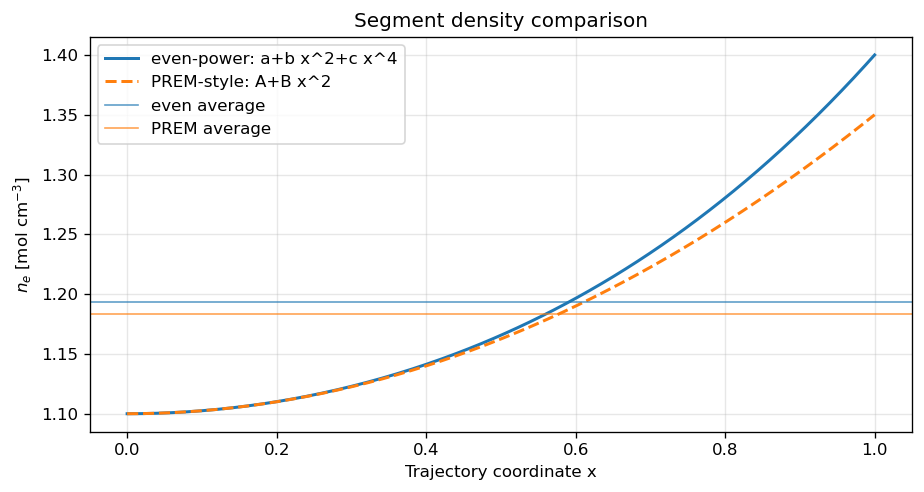

v:\output\diagnostic\core\diagnostic4_fig6_1_model_comparison.png
average difference: 0.010000000000000009


In [10]:
comparison_even = EvenPowerProfileSegment(
    x1=torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype),
    x2=torch.tensor(1.0, device=ctx.device, dtype=ctx.dtype),
    a=torch.tensor(1.10, device=ctx.device, dtype=ctx.dtype),
    b=torch.tensor(0.25, device=ctx.device, dtype=ctx.dtype),
    c=torch.tensor(0.05, device=ctx.device, dtype=ctx.dtype),
    device=ctx.device,
    dtype=ctx.dtype,
)
comparison_prem = PremProfileSegment(
    x1=torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype),
    x2=torch.tensor(1.0, device=ctx.device, dtype=ctx.dtype),
    a=torch.tensor(1.10, device=ctx.device, dtype=ctx.dtype),
    b=torch.tensor(0.25, device=ctx.device, dtype=ctx.dtype),
    device=ctx.device,
    dtype=ctx.dtype,
)

even_curve = comparison_even.a + comparison_even.b * X_GRID**2 + comparison_even.c * X_GRID**4
prem_curve = comparison_prem.a + comparison_prem.b * X_GRID**2

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(to_numpy(X_GRID), to_numpy(even_curve), lw=1.8, label="even-power: a+b x^2+c x^4")
ax.plot(to_numpy(X_GRID), to_numpy(prem_curve), lw=1.8, ls="--", label="PREM-style: A+B x^2")
ax.axhline(float(comparison_even.average.detach().cpu()), color="C0", lw=1.0, alpha=0.7, label="even average")
ax.axhline(float(comparison_prem.average.detach().cpu()), color="C1", lw=1.0, alpha=0.7, label="PREM average")
ax.set_xlabel("Trajectory coordinate x")
ax.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
ax.set_title("Segment density comparison")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic4_fig6_1_model_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("average difference:", float((comparison_even.average - comparison_prem.average).detach().cpu()))

## 7. Summary

The perturbative model layer is the bridge between medium geometry and the spectral evolutor. The interface keeps segment coordinates and model-specific coefficients together while leaving the evolutor to consume only the average potential, segment length, zero-length mask, perturbation mask, and residual integral.

The even-power model supports higher even powers and therefore can capture curvature beyond a quadratic profile. The PREM tabulated model is intentionally simpler inside each shell: linear in $r^2$, and still linear in $x^2$ after the trajectory shift. Both models provide analytic segment averages and analytic oscillatory residual integrals, which is why they are suitable for fast perturbative propagation.

The constant-segment checks are physically important: if the density is constant across the segment, the residual term vanishes and the perturbative evolutor reduces to the exact average-density evolution.